# Euler-Maruyama Forward, SSCS backwards

--- Initializing Generalized Langevin Diffusion ---


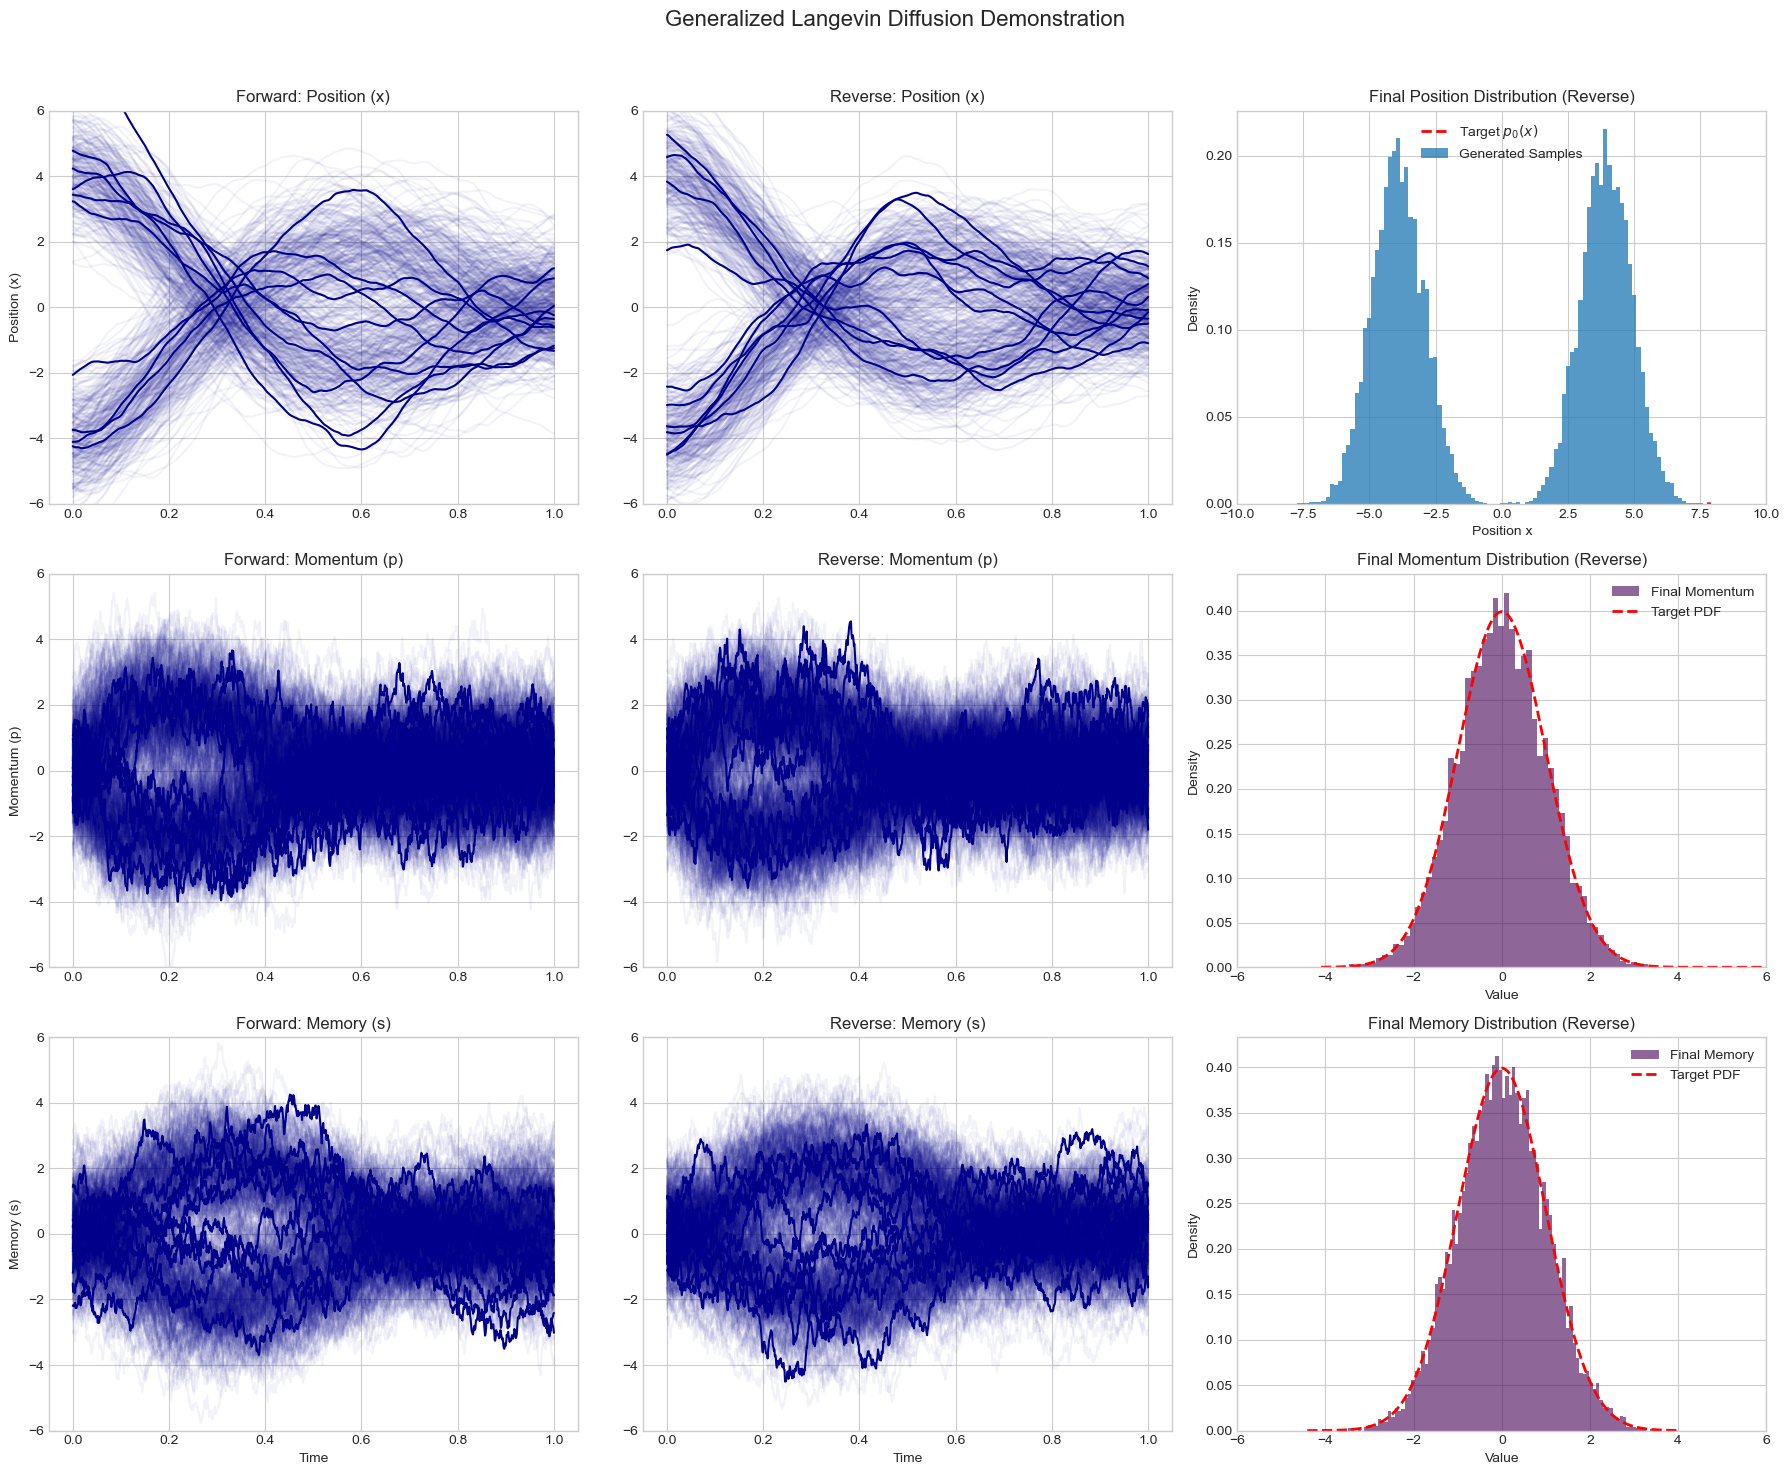

In [2]:
import torch
import math
from diffusion.cld import CriticallyDampedLangevin
from diffusion.gld import GeneralizedLangevinDiffusion
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}
  # gamma = 1.0
n_plot, n_hist = 500, 10000
gld_model = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs2', gamma=math.sqrt(2.0), lambda_val=1.0, c_val=0.9, M=1.0, n_steps=1000)
reverse_sde_paths = gld_model.run_demonstration(n_plot, n_hist)

# cld_model = CriticallyDampedLangevin(GMM_PARAMS)
# cld_model.run_demonstration(n_plot, n_hist)

--- Initializing Generalized Langevin Diffusion ---


/opt/anaconda3/lib/python3.11/site-packages/scipy/linalg/_solvers.py:193: RuntimeWarning: Input "a" has an eigenvalue pair whose sum is very close to or exactly zero. The solution is obtained via perturbing the coefficients.
  warnings.warn('Input "a" has an eigenvalue pair whose sum is '


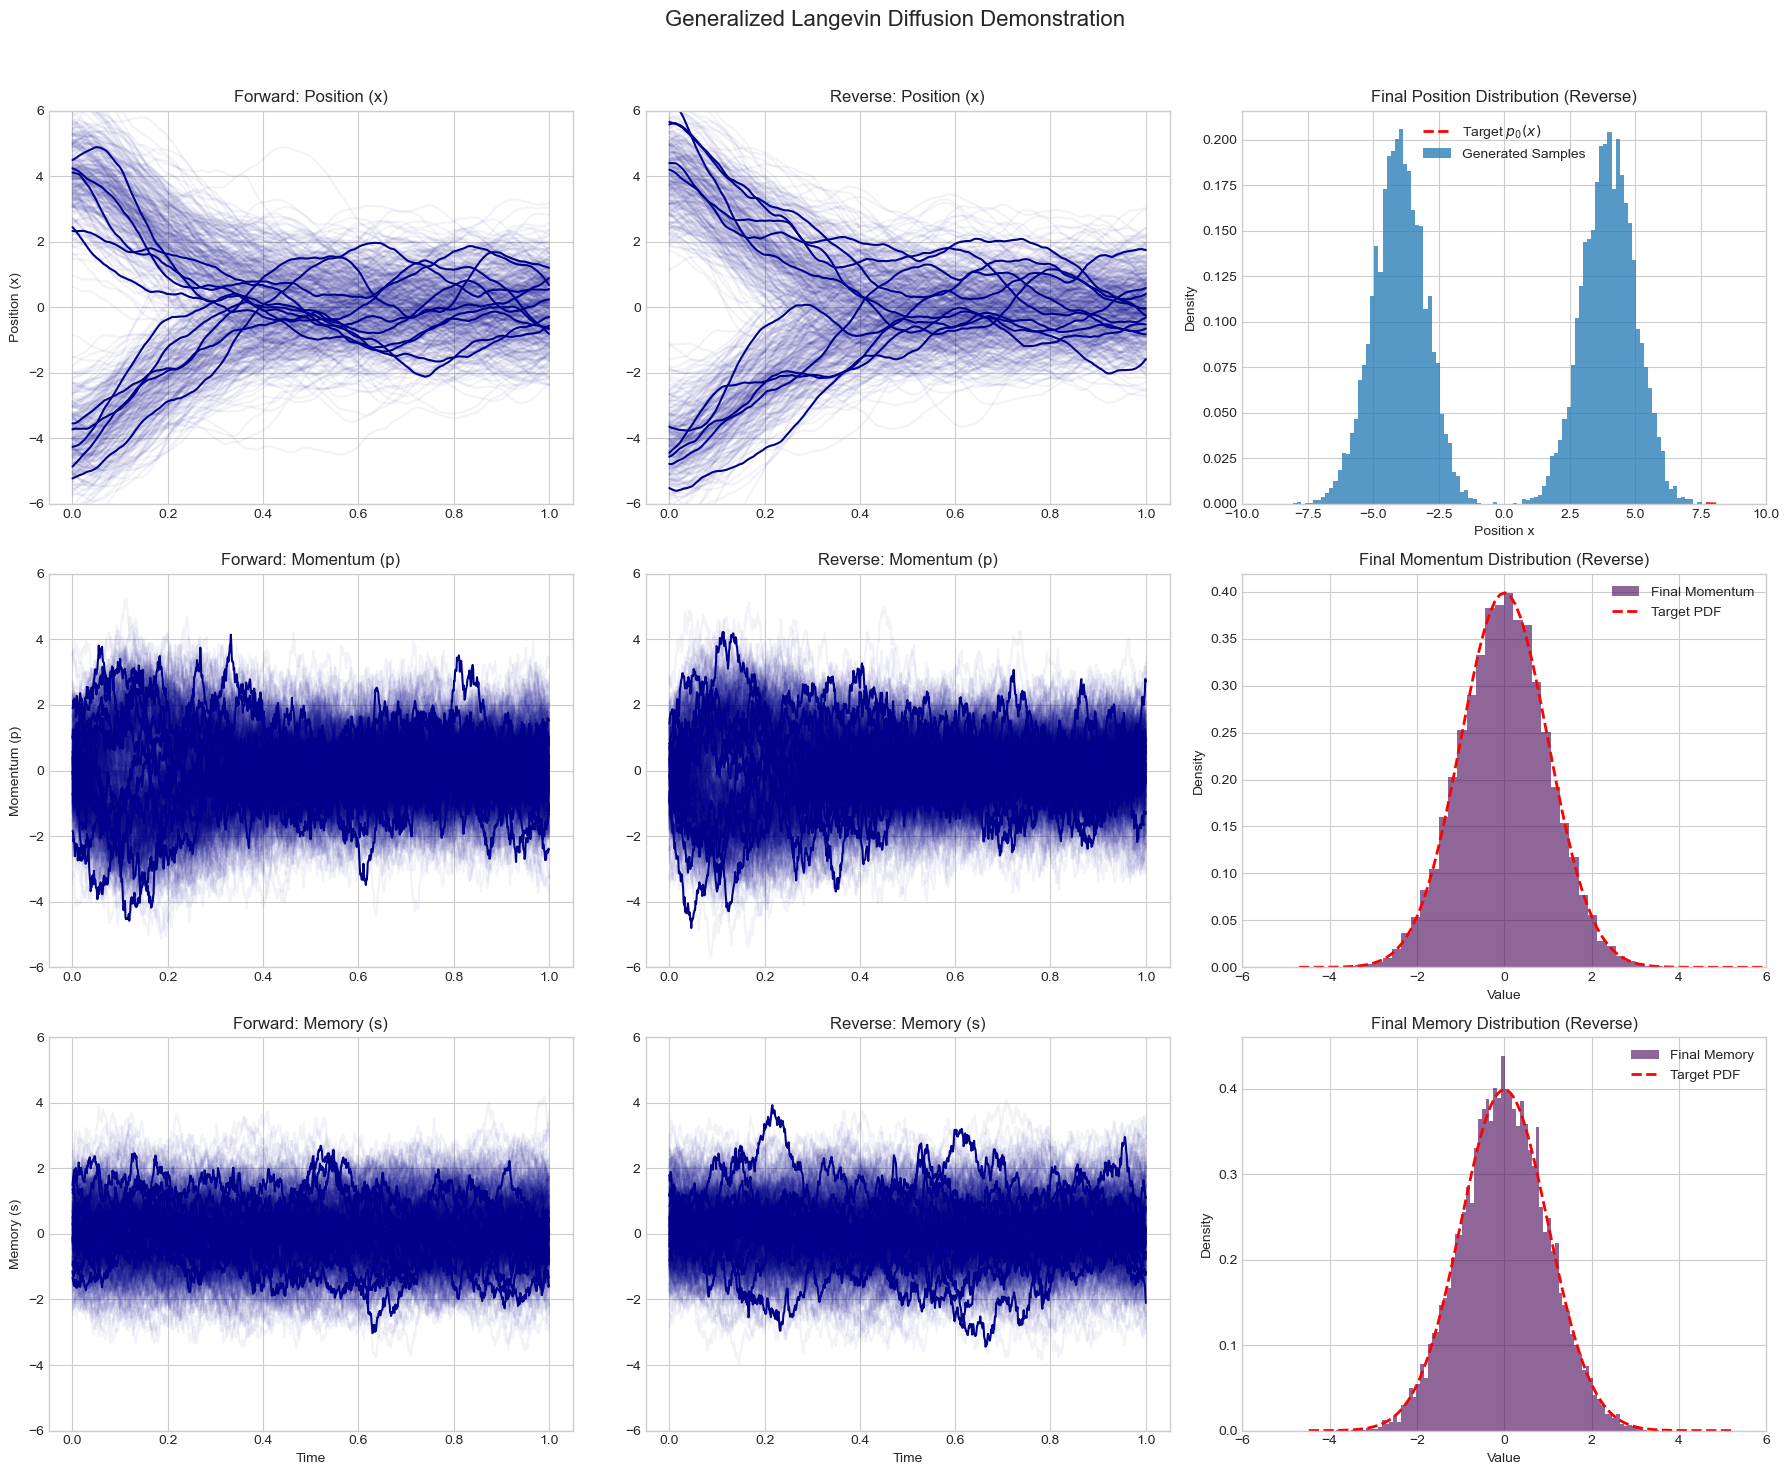

In [3]:
import torch
import numpy as np
import math
from diffusion.cld import CriticallyDampedLangevin
from diffusion.gld import GeneralizedLangevinDiffusion
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}
  # gamma = 1.0
n_plot, n_hist = 500, 10000
gld_model = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs', gamma=math.sqrt(2.0), lambda_val=1.0, c_val=0.0, M=1.0, n_steps=1000)
reverse_sde_paths = gld_model.run_demonstration(n_plot, n_hist)


print("A = " ,gld_model.A)
print("B = ", gld_model.B)
print("C = ", gld_model.C_np)
print("F = ", gld_model.F_half_np)
print("S = ", gld_model.S_half_np)
# print("exp_FO_half = ", gld_model.exp_FO_half)
print("dt = ", gld_model.dt)


In [4]:
import torch
import math
from diffusion.cld import CriticallyDampedLangevin
from diffusion.gld import GeneralizedLangevinDiffusion
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-40., 40.],
    'stds': [1., 1.]
}
  # gamma = 1.0
n_plot, n_hist = 500, 10000
gld_model = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs2', gamma=2.0, lambda_val=1.0, c_val=0.0, n_steps=1000)


--- Initializing Generalized Langevin Diffusion ---


In [5]:
import scipy.linalg
from matrix_exp import stationary_covariance, compute_mean_and_covariance
scipy.linalg.sqrtm(gld_model.F_half_np)
A_np = gld_model.A.cpu().numpy()
G_np = gld_model.G.cpu().numpy()
C_np = stationary_covariance(gld_model.beta, gld_model.A_np, gld_model.G_np)
print("C_np = ", C_np)
#gld_model.F_half_np

# import scipy.linalg
# A_np = gld_model.A.cpu().numpy()
# G_np = gld_model.G.cpu().numpy()
# dt = gld_model.dt.item()
# F_np = scipy.linalg.expm(-gld_model.beta * A_np * dt/2)
        
# A_np = gld_model.A.numpy()
# dt = gld_model.dt.item()
# beta  = gld_model.beta
# scipy.linalg.expm(-beta * A_np * dt/2)


C_np =  [[ 1.0000001e+00 -6.3517007e-08  0.0000000e+00]
 [-7.9959307e-08  9.9999994e-01  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  1.0000000e+00]]


--- Initializing Critically Damped Langevin ---


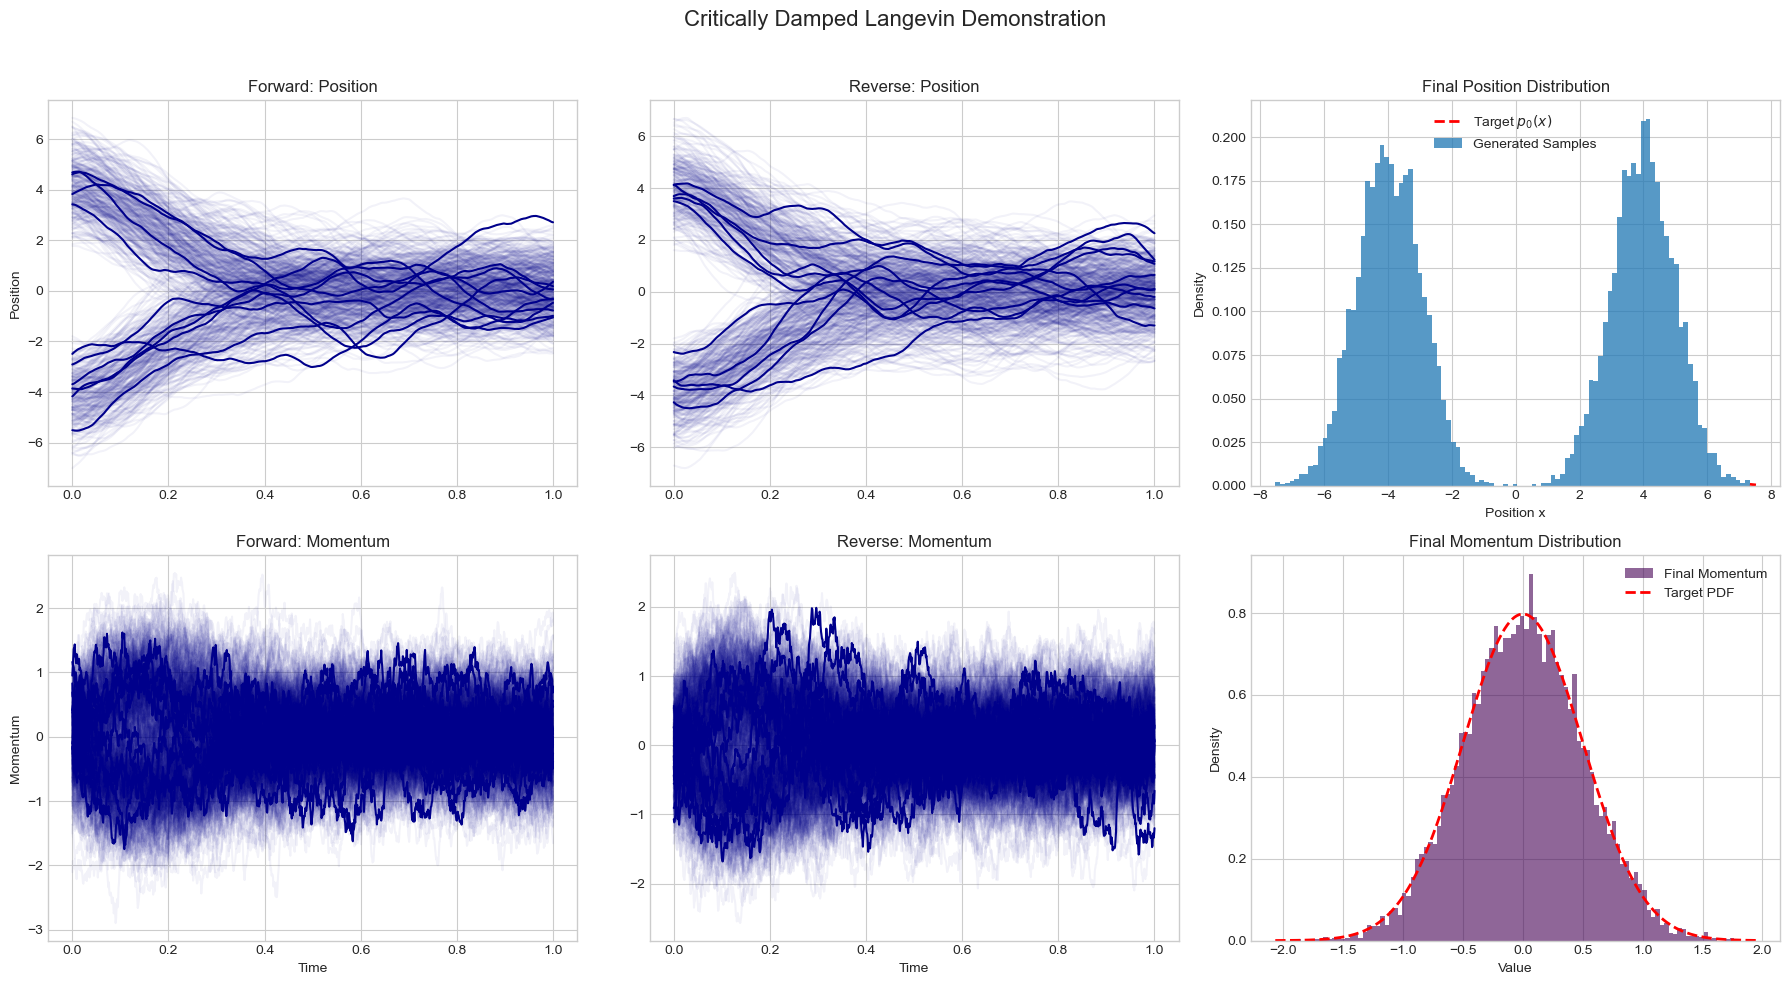

In [6]:
from diffusion.cld import CriticallyDampedLangevin
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}
  # gamma = 1.0
n_plot, n_hist = 500, 10000
cld_model = CriticallyDampedLangevin(GMM_PARAMS, n_steps=1000)
cld_model.run_demonstration(n_plot, n_hist)

# Training VP-SDE

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from diffusion.vpsde import VPSDE

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}

# Train
vpsde = VPSDE(GMM_PARAMS)
model, losses = vpsde.train_score_network_dsm(n_epochs=25, batch_size=128)

# Save model
save_dir = "checkpoints/vpsde"
os.makedirs(save_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(save_dir, "score_net_final.pt"))

# Save loss plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(losses)+1), losses, lw=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Score Network Training Loss")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(save_dir, "training_loss.png"))
plt.close()


--- Initializing VP-SDE ---
[DSM] Epoch 1/25 - Loss: 0.625277
[DSM] Epoch 2/25 - Loss: 0.433896
[DSM] Epoch 3/25 - Loss: 0.410094
[DSM] Epoch 4/25 - Loss: 0.408994
[DSM] Epoch 5/25 - Loss: 0.403594
[DSM] Epoch 6/25 - Loss: 0.402305
[DSM] Epoch 7/25 - Loss: 0.401917
[DSM] Epoch 8/25 - Loss: 0.401726
[DSM] Epoch 9/25 - Loss: 0.397682
[DSM] Epoch 10/25 - Loss: 0.402323
[DSM] Epoch 11/25 - Loss: 0.407035
[DSM] Epoch 12/25 - Loss: 0.402325
[DSM] Epoch 13/25 - Loss: 0.397473
[DSM] Epoch 14/25 - Loss: 0.404857
[DSM] Epoch 15/25 - Loss: 0.403738
[DSM] Epoch 16/25 - Loss: 0.396674
[DSM] Epoch 17/25 - Loss: 0.399260
[DSM] Epoch 18/25 - Loss: 0.399147
[DSM] Epoch 19/25 - Loss: 0.399021
[DSM] Epoch 20/25 - Loss: 0.396219
[DSM] Epoch 21/25 - Loss: 0.399732
[DSM] Epoch 22/25 - Loss: 0.397435
[DSM] Epoch 23/25 - Loss: 0.401586
[DSM] Epoch 24/25 - Loss: 0.401867
[DSM] Epoch 25/25 - Loss: 0.402278


--- Initializing VP-SDE ---
Model successfully loaded from checkpoint.


/var/folders/sx/y6c6vjtn04719m5bcb52hk3r0000gn/T/ipykernel_17578/3067190038.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_

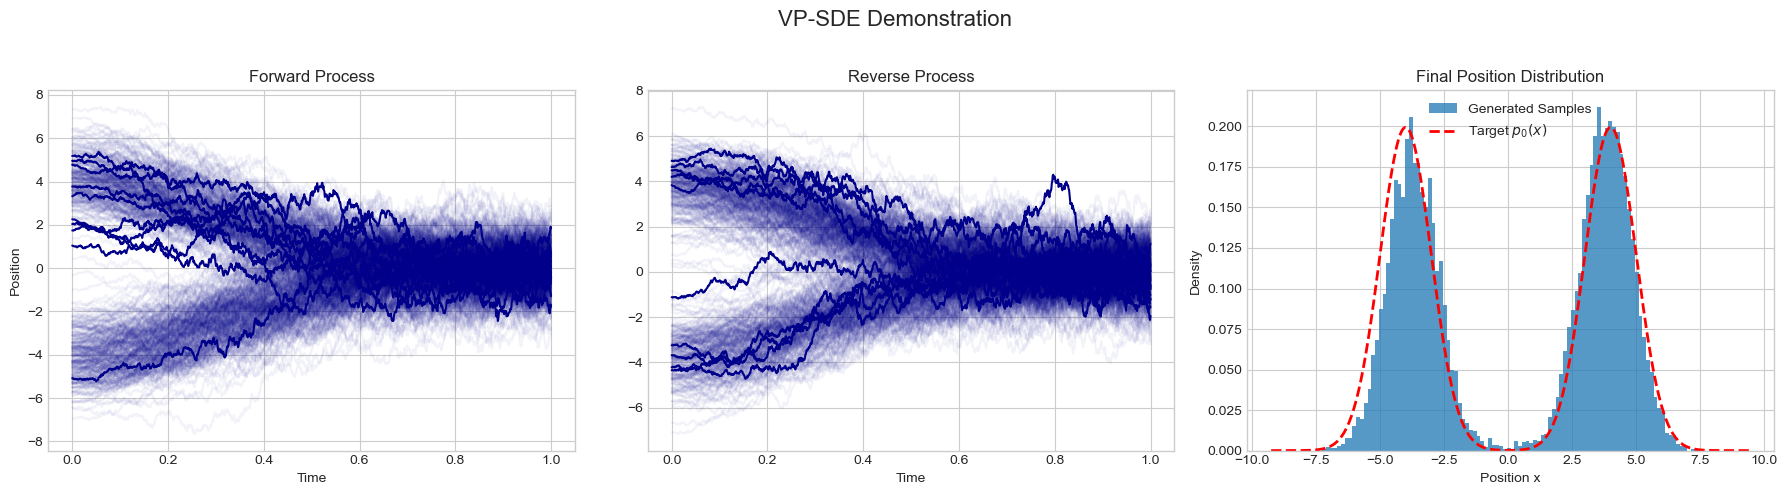

In [3]:
import torch
from models import ScoreNetwork
from diffusion.vpsde import VPSDE

DEVICE = torch.device("cpu")  # or "cuda" if you trained on GPU

# Path to checkpoint
checkpoint_path = "checkpoints/vpsde/score_net_final.pt"

# Recreate the model and load weights
GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}

# Train
vpsde = VPSDE(GMM_PARAMS)

model = ScoreNetwork().to(DEVICE)
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.eval()

print("Model successfully loaded from checkpoint.")
n_plot, n_hist = 500, 10000
model.eval()
vpsde.run_demonstration(n_plot, n_hist, score_model=model)

# Train CLD

--- Initializing Critically Damped Langevin ---
[HSM] Epoch 1/25 - Loss: 3.409709
[HSM] Epoch 2/25 - Loss: 3.267998
[HSM] Epoch 3/25 - Loss: 3.279959
[HSM] Epoch 4/25 - Loss: 3.116116
[HSM] Epoch 5/25 - Loss: 3.109400
[HSM] Epoch 6/25 - Loss: 3.213799
[HSM] Epoch 7/25 - Loss: 3.190803
[HSM] Epoch 8/25 - Loss: 3.169678
[HSM] Epoch 9/25 - Loss: 3.160897
[HSM] Epoch 10/25 - Loss: 3.146672
[HSM] Epoch 11/25 - Loss: 3.111886
[HSM] Epoch 12/25 - Loss: 3.162588
[HSM] Epoch 13/25 - Loss: 3.188679
[HSM] Epoch 14/25 - Loss: 3.181832
[HSM] Epoch 15/25 - Loss: 3.140265
[HSM] Epoch 16/25 - Loss: 3.180280
[HSM] Epoch 17/25 - Loss: 3.235612
[HSM] Epoch 18/25 - Loss: 3.179037
[HSM] Epoch 19/25 - Loss: 3.120978
[HSM] Epoch 20/25 - Loss: 3.214537
[HSM] Epoch 21/25 - Loss: 3.163394
[HSM] Epoch 22/25 - Loss: 3.125296
[HSM] Epoch 23/25 - Loss: 3.235086
[HSM] Epoch 24/25 - Loss: 3.150886
[HSM] Epoch 25/25 - Loss: 3.205455
Training complete. Model + loss plot saved in checkpoints/cld


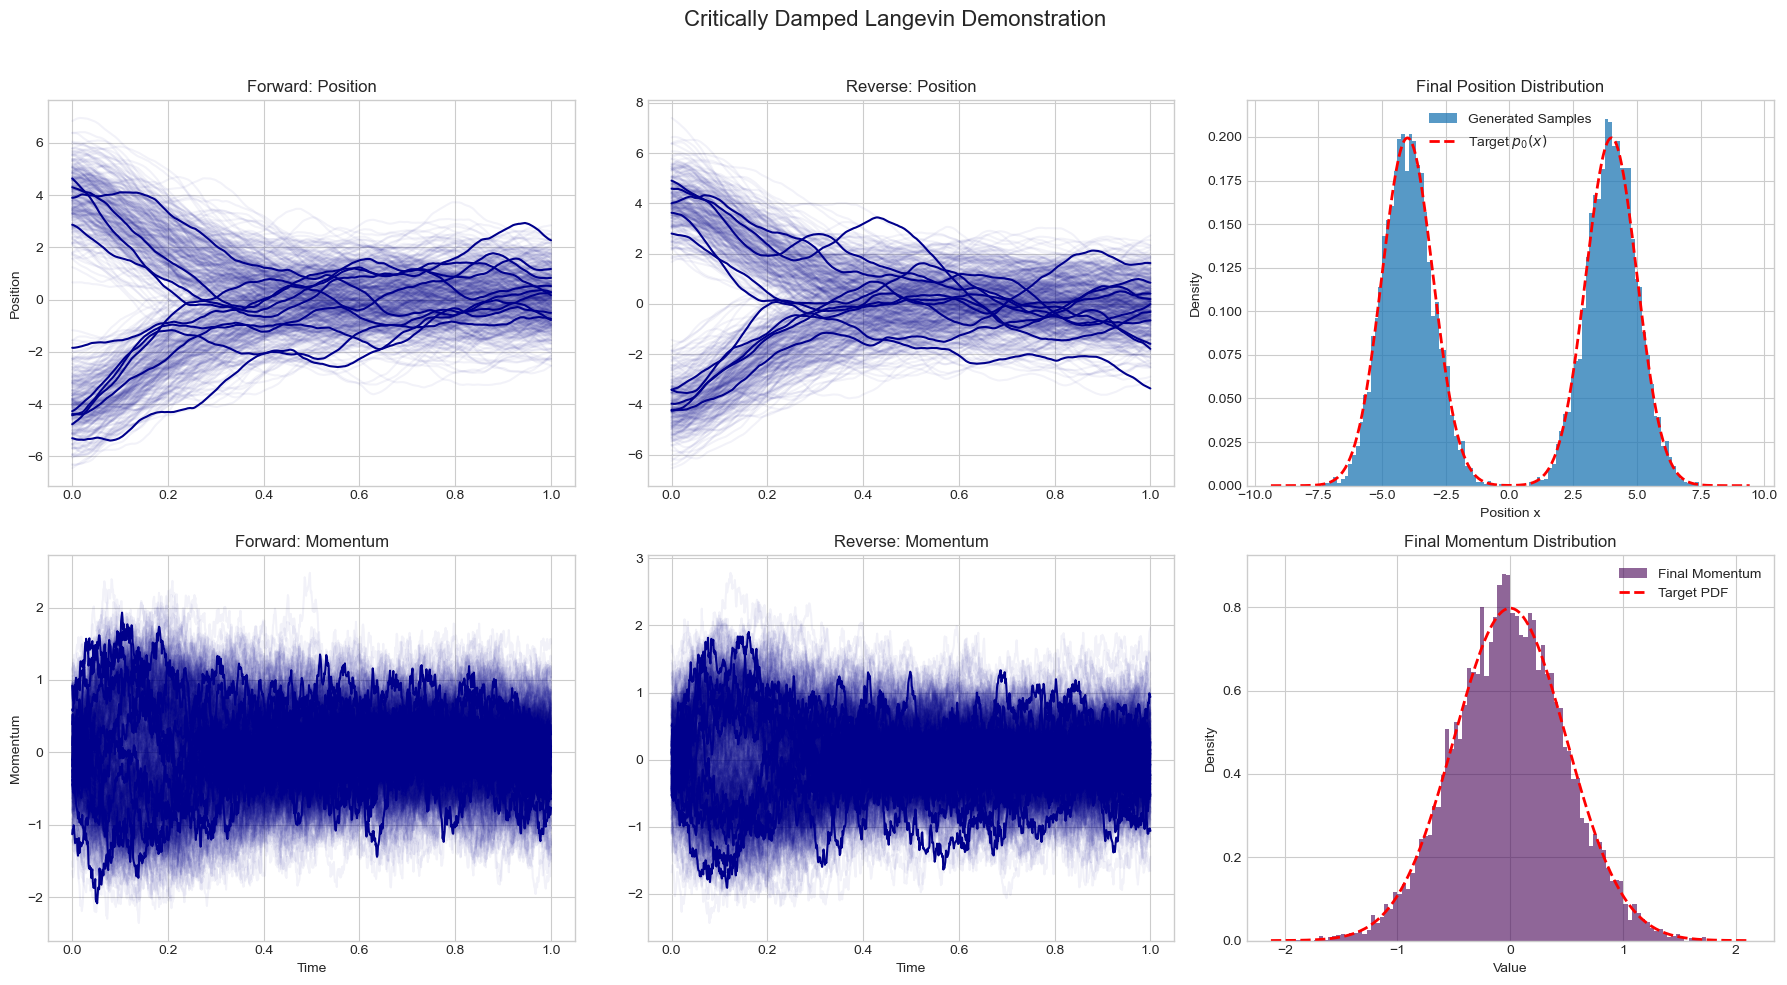

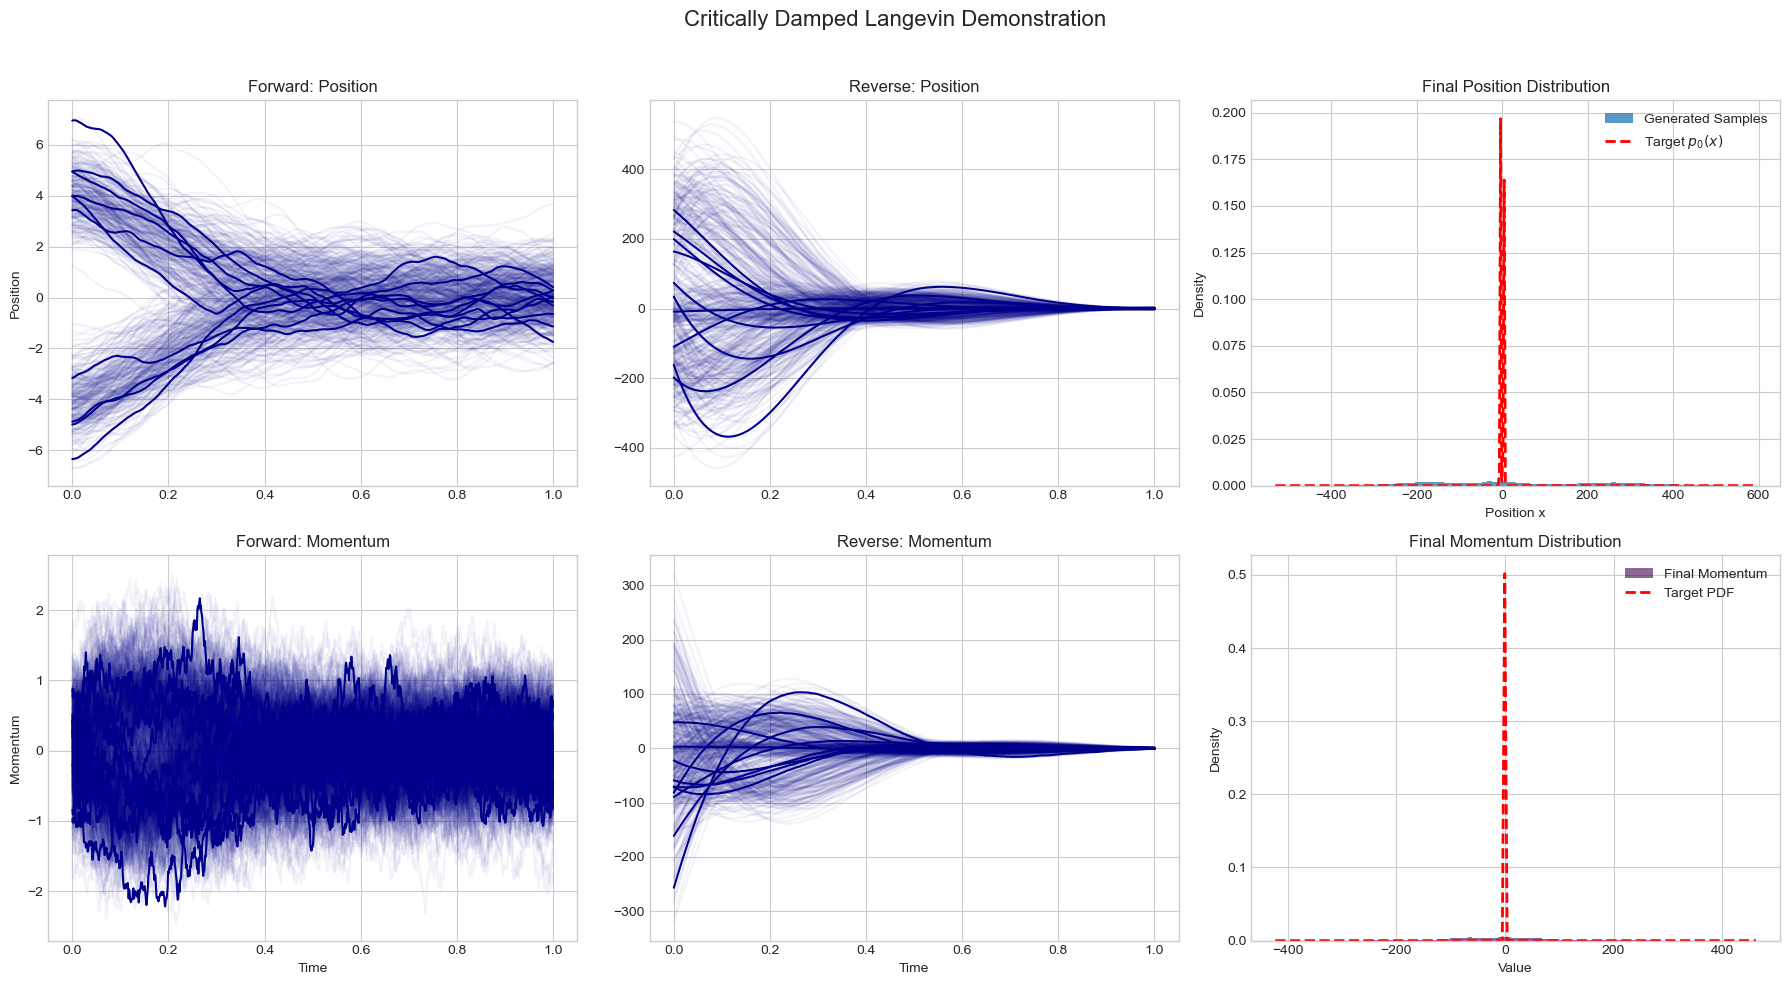

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from diffusion.cld import CriticallyDampedLangevin
from models import CLDScoreNetwork

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}

# Initialize CLD
cld = CriticallyDampedLangevin(GMM_PARAMS)

# Train with Hybrid Score Matching
model, losses = cld.train_score_network_hsm(
    CLDScoreNetwork, n_epochs=25, batch_size=128, lr=1e-3
)

# Save model + training loss
save_dir = "checkpoints/cld"
os.makedirs(save_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(save_dir, "score_net_final.pt"))

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses)+1), losses, lw=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CLD Hybrid Score Matching Loss")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(save_dir, "training_loss.png"))
plt.close()

print("Training complete. Model + loss plot saved in", save_dir)

n_plot, n_hist = 500, 10000
model.eval()
cld.run_demonstration(n_plot, n_hist)                     # Ground-truth
cld.run_demonstration(n_plot, n_hist, score_model=model)  # Learned